# Natural Convection with Localized Bottom Heating

This notebook drives the solver in `src/solver.py` to simulate 2D natural convection in a rectangular cavity with a localized heated patch on the middle third of the bottom wall.

Physics: incompressible Navier–Stokes with the Boussinesq approximation for buoyancy, coupled to a temperature transport equation. Numerics: fractional-step projection method on a staggered MAC grid; pressure Poisson solved by SOR; 1st-order upwind convection for temperature.

The solver itself is plotting-free; this notebook supplies a callback that records diagnostics and renders the live visualization.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

import solver

## 1. Set up parameters and run the simulation

Edit the `Params(...)` call to change the case. Anything you don't pass uses the defaults defined in `solver.py`.

In [2]:
p = solver.Params(
    Lx=3.0, Ly=2.0,
    Nx=121, Ny=81,
    Ra=1.0e6, Pr=0.71,
    T_hot=4.0, T_cold=1.0,
    Uwall=0.01,
    endT=20.0,
)
g = solver.Grid.from_params(p)
state = solver.State.zeros(p)
state.T = solver.initial_temperature(p, g)
solver.set_bc_temp(state.T, p, g)

dt = solver.compute_dt(p, g)
Uref = solver.reference_velocity(p)
Nt = int(p.endT * p.Lx / Uref / dt)
gbeta = solver.buoyancy_coefficient(p)
T_ref = 0.5 * (p.T_hot + p.T_cold)

print(f'dt = {dt:.4e},  Nt = {Nt},  g*beta = {gbeta:.4e}')

dt = 5.0000e-01,  Nt = 11999,  g*beta = 4.1667e-04


## 2. Diagnostics storage and plotting helper

Here record max/avg temperature, mean heat-flux magnitude, and an L2 deviation from the pure-conduction (linear) reference at each plotted snapshot. The plot uses a `yc_plot` shifted to [0, 2] so `streamplot` is happy with a strictly increasing y-axis.

In [3]:
history = {
    'time': [],
    'max_T': [],
    'avg_T': [],
    'mean_flux': [],
    'l2_error': [],
}
yc_plot = np.linspace(0.0, 2.0, p.Ny + 1)

def render(state, t):
    qx, qy = solver.heat_flux(state.T, g, p.kappa)
    flux_mag = np.sqrt(qx**2 + qy**2)
    T_lin = solver.linear_reference_T(p, g)

    history['time'].append(t)
    history['max_T'].append(float(state.T.max()))
    history['avg_T'].append(float(state.T.mean()))
    history['mean_flux'].append(float(flux_mag.mean()))
    history['l2_error'].append(solver.l2_error(state.T, T_lin))

    fig = plt.figure(figsize=(20, 12))

    # Pressure + streamlines
    ax1 = plt.subplot(231)
    cf = ax1.contourf(g.xc, yc_plot, state.p)
    plt.colorbar(cf, ax=ax1)
    uc = 0.5 * (state.u[:, :-1] + state.u[:, 1:]) / Uref
    vc = 0.5 * (state.v[:-1, :] + state.v[1:, :]) / Uref
    ax1.streamplot(g.xc, yc_plot, uc, vc, color='w', density=1.5)
    ax1.set(title='Flow field (pressure + streamlines)', xlim=(0, p.Lx), ylim=(0, p.Ly))
    ax1.set_aspect('equal')
    ax1.set_yticks([0, 1, 2]); ax1.set_yticklabels(['-1', '0', '1'])

    # Temperature
    ax2 = plt.subplot(232)
    levels = np.linspace(p.T_cold, p.T_hot, 20)
    cf = ax2.contourf(g.xc, yc_plot, state.T, levels=levels, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax2)
    ax2.set(title='Temperature', xlim=(0, p.Lx), ylim=(0, p.Ly))
    ax2.set_aspect('equal')
    ax2.set_yticks([0, 1, 2]); ax2.set_yticklabels(['-1', '0', '1'])

    # Heat flux magnitude
    ax3 = plt.subplot(233)
    cf = ax3.contourf(g.xc, yc_plot, flux_mag, cmap='hot')
    plt.colorbar(cf, ax=ax3)
    ax3.set(title='Heat flux magnitude', xlim=(0, p.Lx), ylim=(0, p.Ly))
    ax3.set_aspect('equal')
    ax3.set_yticks([0, 1, 2]); ax3.set_yticklabels(['-1', '0', '1'])

    # Temperature evolution
    ax4 = plt.subplot(234)
    ax4.plot(history['time'], history['max_T'], 'r-', label='Max T')
    ax4.plot(history['time'], history['avg_T'], 'b-', label='Mean T')
    ax4.set(xlabel='time', ylabel='Temperature'); ax4.grid(True); ax4.legend()

    # L2 deviation from conduction reference
    ax5 = plt.subplot(235)
    ax5.plot(history['time'], history['l2_error'], 'k-')
    ax5.set(xlabel='time', ylabel='L2 dev. from linear T'); ax5.grid(True)

    plt.tight_layout()
    plt.show()
    plt.pause(0.01)

## 3. Main loop

I use `solver.step` directly inside the loop instead of `solver.run`, so the notebook owns the progress bar and visualization.

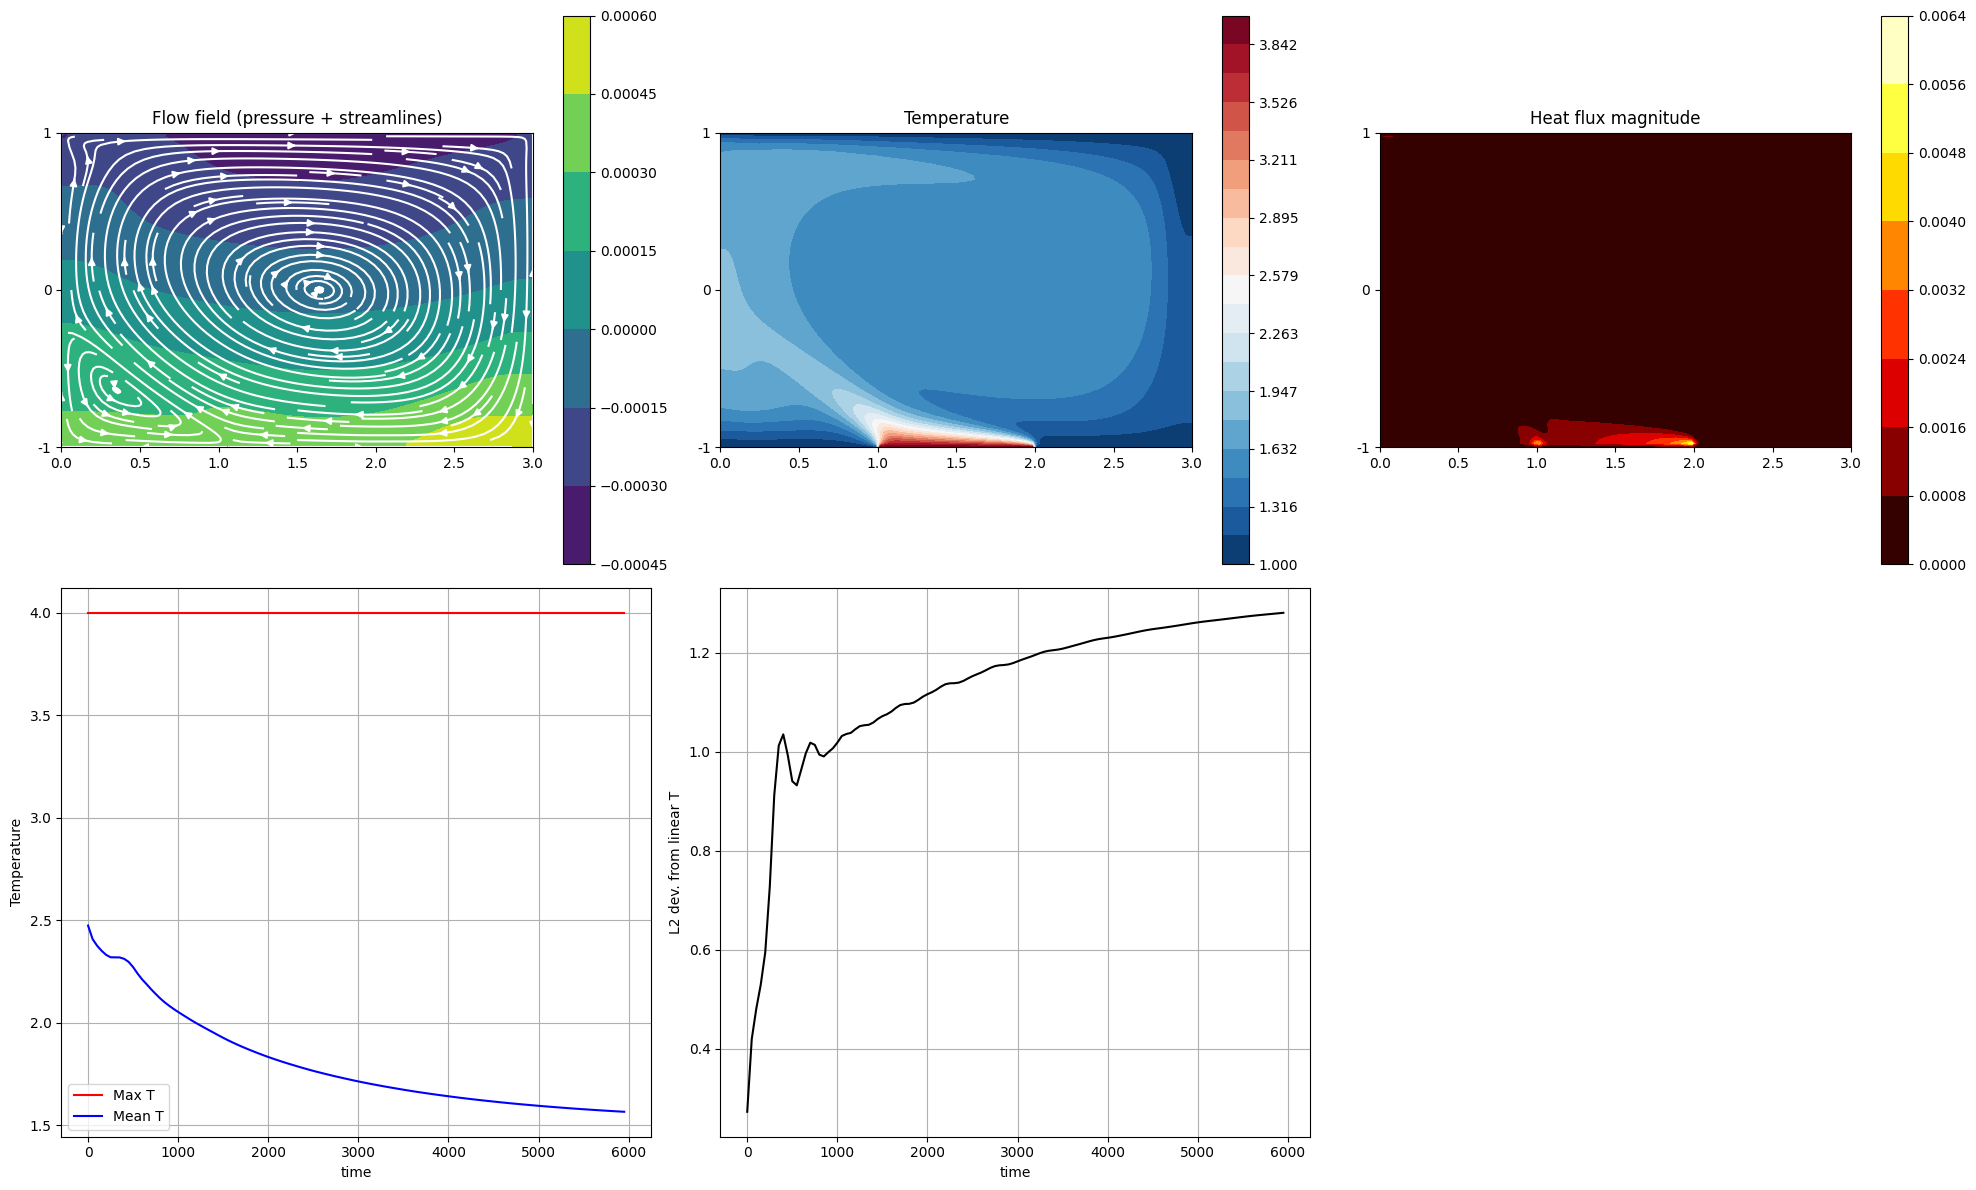

Elapsed: 11821.7 s


In [4]:
plt.ion()
t0 = time.time()
for itr in tqdm(range(Nt)):
    solver.step(state, p, g, dt, gbeta, T_ref)
    if itr % 100 == 0:
        clear_output(wait=True)
        render(state, itr * dt)
plt.ioff()
print(f'Elapsed: {time.time() - t0:.1f} s')

## 4. Save results

In [5]:
os.makedirs('../results', exist_ok=True)
np.savez('../results/simulation_results.npz',
         time=history['time'],
         max_T=history['max_T'],
         avg_T=history['avg_T'],
         mean_flux=history['mean_flux'],
         l2_error=history['l2_error'],
         T_final=state.T,
         u_final=state.u,
         v_final=state.v,
         p_final=state.p)

print('Simulation complete.')
print(f"  Final mean T : {history['avg_T'][-1]:.3f}")
print(f"  Final max  T : {history['max_T'][-1]:.3f}")
print(f"  Final L2 dev : {history['l2_error'][-1]:.3e}")

Simulation complete.
  Final mean T : 1.565
  Final max  T : 4.000
  Final L2 dev : 1.281e+00
